# Agent Performance Analysis

In this notebook, the performance of the system is analyzed, with a particular focus on the agent’s ability to correctly extract relevant information from user requests. Additionally, the overall accuracy of the system is evaluated with respect to the varying difficulty levels of the input prompts.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from pandas import DataFrame

## Analysis of Item Recognition in User Prompts

In this section, the extent to which user prompts are sufficiently detailed to enable the agent to correctly identify items is analyzed. In particular, the focus is on the recognition of product codes as well as general commercial items, including their associated models when available.

In [2]:
agent_test_file: str = "./tables/agent_test_results.csv"

data_frame: DataFrame = pd.read_csv(
    agent_test_file, 
    header = 2
)

data_frame["accuratezza"] = (
    data_frame["accuratezza"]
    .astype(str)
    .str.replace("%", "", regex = False)
    .str.replace(",", ".", regex = False)
    .astype(float) / 100
)

data_frame["sito_web"] = (
    data_frame["sito_web"]
    .astype(str)
    .str.strip()
    .str.upper()
)

data_frame["metodo_reperimento_dati"] = (
    data_frame["metodo_reperimento_dati"]
    .astype(str)
    .str.strip()
)

Once the dataset has been loaded and cleaned to remove inconsistencies introduced during the import from Google Sheets, the analysis proceeds with the generation of the first plot. This visualization aims to evaluate the agent’s ability to correctly extract products from user prompts.

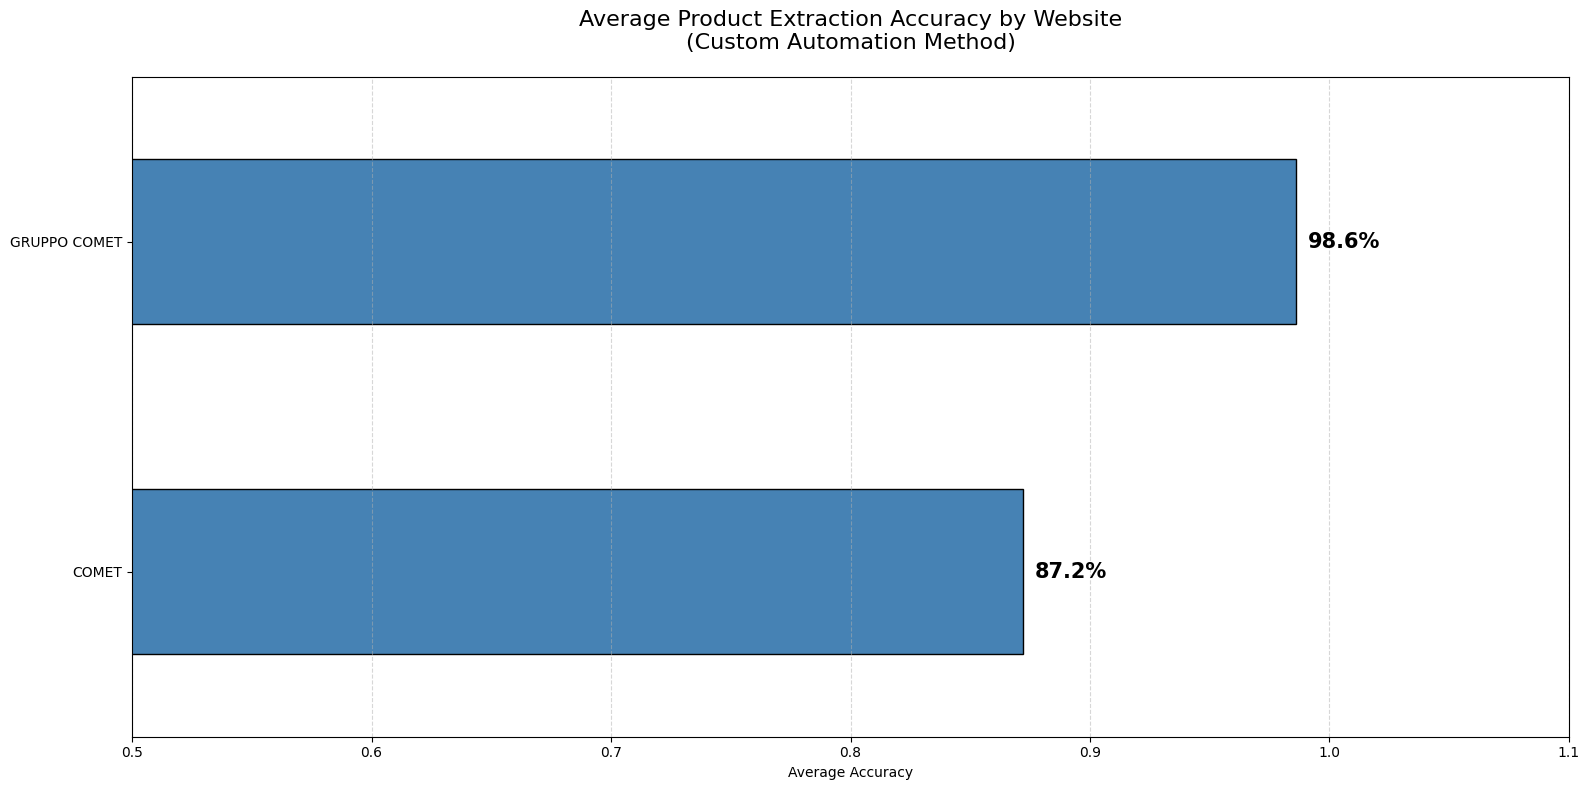

In [ ]:
target_method: str = "automazione custom"

df_custom: DataFrame = data_frame[
    data_frame["metodo_reperimento_dati"] == target_method
].copy()

site_performance = (
    df_custom.groupby("sito_web")["accuratezza"]
    .mean()
    .sort_values(ascending = True)
)

plt.figure(figsize = (12, 8))

ax = site_performance.plot(
    kind = "barh", 
    color = "steelblue",
    edgecolor = "black"
)

plt.title(
    (
        "Average Product Extraction Accuracy by Website\n"
        "(Custom Automation Method)"
    ),
    fontsize = 16, 
    pad = 20
)

plt.xlabel("Average Accuracy")
plt.ylabel("")
plt.xlim(0.50, 1.10)
plt.grid(
    axis = "x", 
    linestyle = "--", 
    alpha = 0.5
)

for i, v in enumerate(site_performance):
    ax.text(
        v + 0.005, 
        i, 
        f"{v:.1%}", 
        va = "center",
        fontsize = 15,
        fontweight = "bold"
    )

plt.tight_layout()
plt.show()

As shown in the plot, the accuracy achieved on the professional website (Gruppo Comet) is higher. This can be explained by the fact that the system prompt provides more effective guidance to the agent in recognizing structured product codes, as opposed to general commercial items that may or may not include a clearly defined model. 


## Impact of Prompt Difficulty on Product Extraction Accuracy

In this section, we analyze the effect of input prompt difficulty on the agent’s accuracy.

/var/folders/n7/nk76r89x3yqgygrhtqvwvd500000gn/T/ipykernel_88395/38228699.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(


<Figure size 1200x800 with 0 Axes>

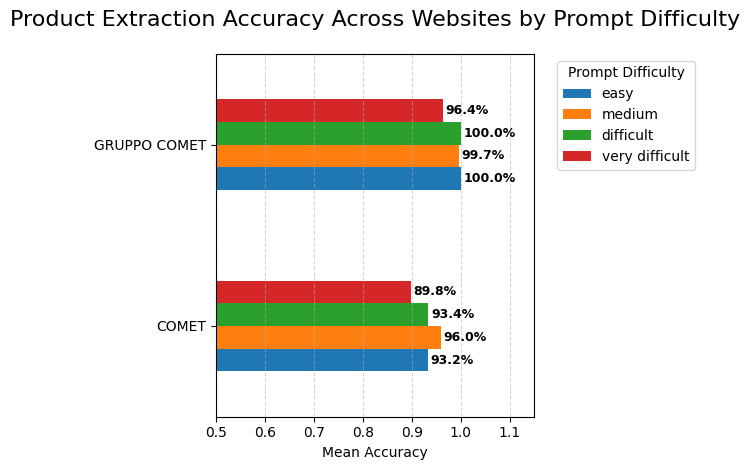

In [ ]:
difficulty_order: list[str] = [
    "facile", 
    "media", 
    "difficile",
    "molto difficile"
]

data_frame["complessita_messaggio"] = pd.Categorical(
    data_frame["complessita_messaggio"],
    categories = difficulty_order,
    ordered = True
)

prompt_performance = (
    data_frame
    .groupby(
        ["sito_web", "complessita_messaggio"]
    )["accuratezza"]
    .mean()
    .unstack()
)

prompt_performance = prompt_performance[
    difficulty_order
]

plt.figure(figsize = (12, 8))

ax = prompt_performance.plot(
    kind = "barh"
)

plt.title(
    (
        "Product Extraction Accuracy Across "
        "Websites by Prompt Difficulty"
    ),
    fontsize = 16, 
    pad = 20
)

plt.xlabel("Mean Accuracy")
plt.ylabel("")

plt.legend(
    title = "Prompt Difficulty", 
    labels = [
        "easy", 
        "medium", 
        "difficult", 
        "very difficult"
    ],
    bbox_to_anchor = (1.05, 1), 
    loc = "upper left"
)

plt.xlim(0.50, 1.15)
plt.grid(
    axis = "x", 
    linestyle = "--", 
    alpha = 0.5
)

for barra in ax.patches:
    larghezza = barra.get_width()
    y = barra.get_y() + barra.get_height() / 2
    
    ax.text(
        larghezza + 0.005,
        y,
        f"{larghezza:.1%}",
        va = "center",
        fontsize = 9,
        fontweight = "bold"
    )

plt.tight_layout()
plt.show()

As shown in the plot, the average accuracy remains higher on the professional website in all cases. On the commercial website, however, an interesting phenomenon can be observed: the average accuracy is higher for prompts of “medium” difficulty, which contain five products, compared to other levels, particularly the “easy” prompts, which include only a single item.

In the “difficult” and “very difficult” cases, the accuracy drops significantly. This is partly due to the fact that these prompts contain ten products, plus an additional item that may be unusual, such as the tungsten cube, intentionally included as an atypical object, or another product that may or may not be available on the website. Such complexity increases the likelihood of extraction errors and demonstrates the limitations of the agent when handling longer and less predictable prompts.


## Comparison of Average Execution Time: Human vs AI

In this section, we analyze the average execution time required to complete product searches, comparing a single human operator with the AI agent. The goal is to highlight the potential time savings achieved by the AI system while maintaining accuracy.

**Note**: The human operator was instructed only to perform the product searches by reading the prompts, essentially acting as the agent, but did not record or store the main product information on any persistent medium. In contrast, the AI agent’s time accounts for both the search and the presentation of the data through the interface.

/var/folders/n7/nk76r89x3yqgygrhtqvwvd500000gn/T/ipykernel_88395/2697645538.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(


<Figure size 1200x800 with 0 Axes>

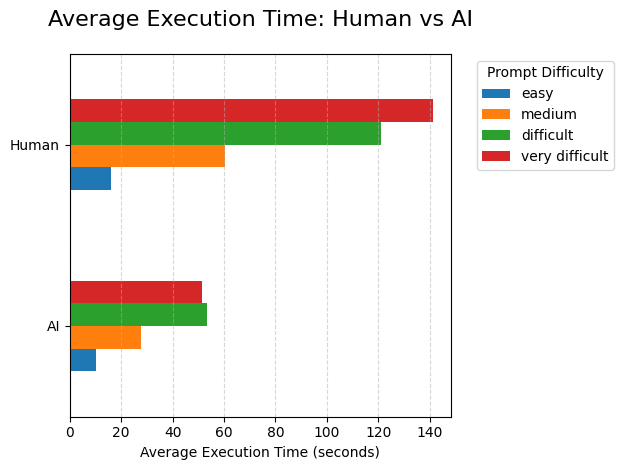

In [18]:
difficulty_order: list[str] = [
    "facile", 
    "media", 
    "difficile",
    "molto difficile"
]

data_frame["complessita_messaggio"] = pd.Categorical(
    data_frame["complessita_messaggio"],
    categories = difficulty_order,
    ordered = True
)

data_frame["esecutore_label"] = (
    data_frame["esecutore"]
    .replace({
        "umano": "Human",
        "IA": "AI"
    })
)

prompt_performance = (
    data_frame
    .groupby(
        ["esecutore_label", "complessita_messaggio"]
    )["tempo_totale_sec"]
    .mean()
    .unstack()
)

prompt_performance = prompt_performance[
    difficulty_order
]

plt.figure(figsize = (12, 8))

ax = prompt_performance.plot(
    kind = "barh"
)

plt.title(
    "Average Execution Time: Human vs AI",
    fontsize = 16, 
    pad = 20
)

plt.xlabel("Average Execution Time (seconds)")
plt.ylabel("")

plt.legend(
    title = "Prompt Difficulty", 
    labels = [
        "easy", 
        "medium", 
        "difficult", 
        "very difficult"
    ],
    bbox_to_anchor = (1.05, 1), 
    loc = "upper left"
)

plt.grid(
    axis = "x", 
    linestyle = "--", 
    alpha = 0.5
)

plt.tight_layout()
plt.show()

As shown in the plots, the time savings achieved by the hybrid scraping agent are remarkable, with the exception of the simplest prompts. On average, the agent equipped with the hybrid scraping tool consistently remains under one minute, whereas a human operator requires over two minutes for the more complex and lengthy prompts.


# Comparison of Automation vs Computer Use: Execution Time, Cost, and Accuracy by Prompt Difficulty

In this section, we compare the performance of the custom automation system with that of a standard computer-assisted workflow, powered by Google Gemini Computer Use. The analysis focuses on three key metrics across different prompt difficulty levels: average execution time, average call cost, and product extraction accuracy. This allows us to evaluate both efficiency and cost-effectiveness of the automation.

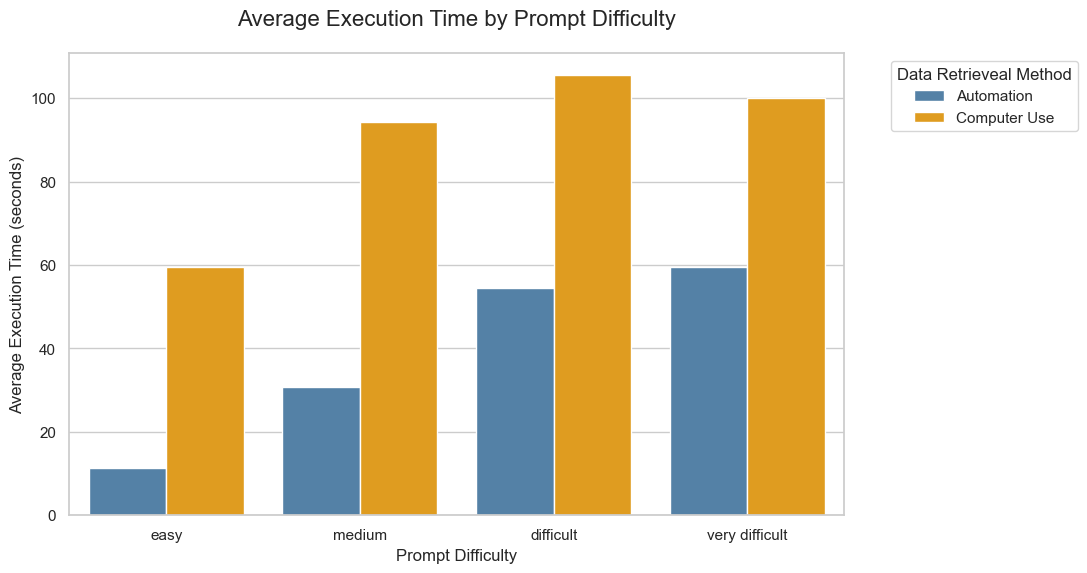

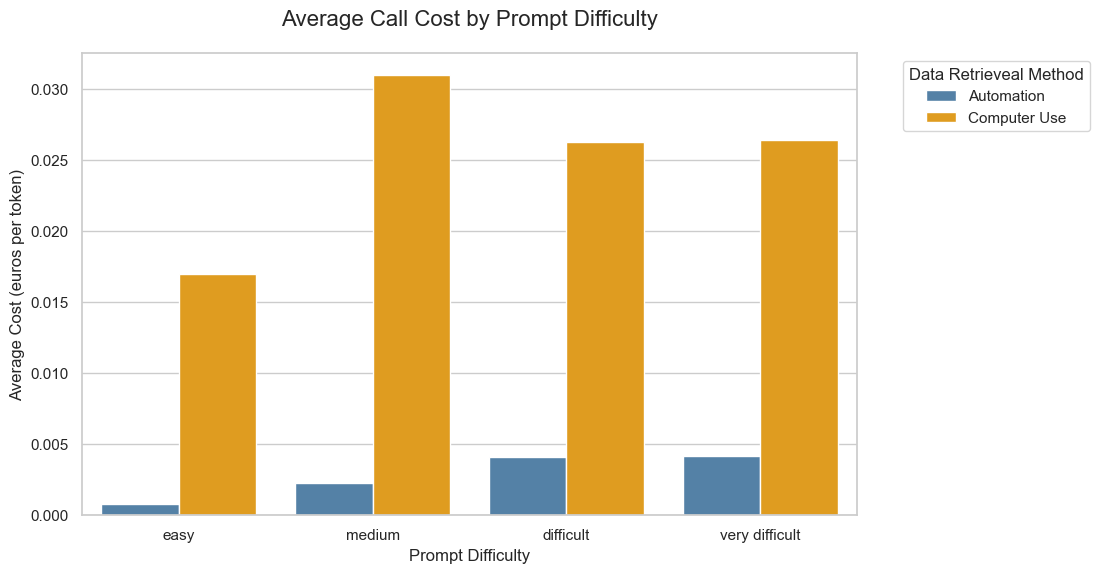

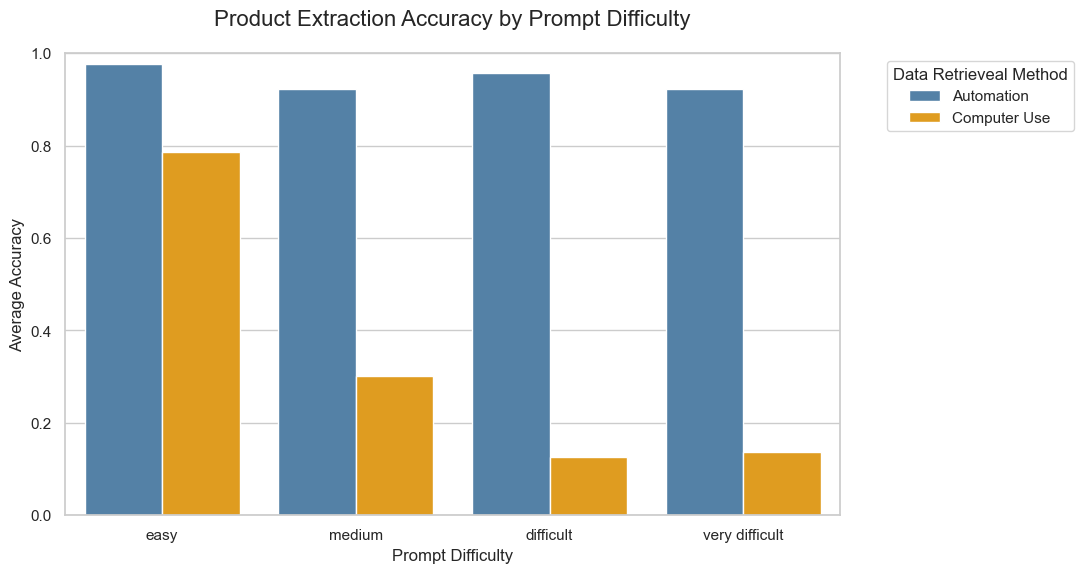

In [52]:
import seaborn as sns


agent_vs_computer_use_file: str = (
    "./tables/automation_vs_computer_use_results.csv"
)

data_frame: DataFrame = pd.read_csv(
    agent_vs_computer_use_file, 
    header = 0
)

data_frame["metodo_label"] = (
    data_frame["metodo_reperimento_dati"]
    .replace({
        "automazione custom": "Automation",
        "computer use": "Computer Use"
    })
)

data_frame["complessita_messaggio_label"] = (
    data_frame["complessita_messaggio"]
    .replace({
        "facile": "easy",
        "media": "medium",
        "difficile": "difficult",
        "molto difficile": "very difficult"
    })
)

ordine_difficolta = [
    "facile", 
    "media", 
    "difficile", 
    "molto difficile"
]

data_frame["complessita_messaggio"] = pd.Categorical(
    data_frame["complessita_messaggio"],
    categories=ordine_difficolta,
    ordered=True
)

data_frame["accuratezza"] = (
    data_frame["accuratezza"]
    .astype(str)
    .str.replace("%", "", regex = False)
    .str.replace(",", ".", regex = False)
    .astype(float) / 100
)

data_frame["metodo_reperimento_dati"] = (
    data_frame["metodo_reperimento_dati"]
    .astype(str)
    .str.strip()
)

for col in ["tempo_totale_sec", "costo_euro", "accuratezza"]:
    data_frame[col] = (
        data_frame[col]
        .astype(str)
        .str.replace(",", ".", regex = False)
        .str.strip()
        .astype(float)
    )

metrics = (
    data_frame
    .groupby(
        ["metodo_label", "complessita_messaggio_label"]
    )[
        ["tempo_totale_sec", "costo_euro", "accuratezza"]
    ]
    .mean()
    .reset_index()
)

sns.set_theme(style = "whitegrid")


plt.figure(figsize = (10, 6))
sns.barplot(
    x = "complessita_messaggio_label",
    y = "tempo_totale_sec",
    hue = "metodo_label",
    order = [
        "easy", 
        "medium", 
        "difficult", 
        "very difficult"
    ],
    data = metrics,
    palette = ["steelblue", "orange"]
)
plt.title(
    "Average Execution Time by Prompt Difficulty", 
    fontsize = 16,
    pad = 20
)
plt.xlabel("Prompt Difficulty")
plt.ylabel("Average Execution Time (seconds)")
plt.legend(
    title = "Data Retrieveal Method", 
    bbox_to_anchor = (1.05, 1)
)
plt.show()


plt.figure(figsize = (10, 6))
sns.barplot(
    x = "complessita_messaggio_label",
    y = "costo_euro",
    hue = "metodo_label",
    order = [
        "easy", 
        "medium", 
        "difficult", 
        "very difficult"
    ],
    data = metrics,
    palette = ["steelblue", "orange"]
)
plt.title(
    "Average Call Cost by Prompt Difficulty", 
    fontsize = 16,
    pad = 20
)
plt.xlabel("Prompt Difficulty")
plt.ylabel("Average Cost (euros per token)")
plt.legend(
    title = "Data Retrieveal Method",
    bbox_to_anchor = (1.31, 1)
)
plt.show()


plt.figure(figsize = (10, 6))
sns.barplot(
    x = "complessita_messaggio_label",
    y = "accuratezza",
    hue = "metodo_label",
    order = [
        "easy", 
        "medium", 
        "difficult", 
        "very difficult"
    ],
    data = metrics,
    palette = ["steelblue", "orange"]
)
plt.title(
    "Product Extraction Accuracy by Prompt Difficulty", 
    fontsize = 16,
    pad = 20
)
plt.xlabel("Prompt Difficulty")
plt.ylabel("Average Accuracy")
plt.ylim(0, 1.0)
plt.legend(
    title = "Data Retrieveal Method",
    bbox_to_anchor = (1.05, 1)
)
plt.show()

The first plot shows that the agent using the hybrid scraping tool consistently remains below one minute on average, approaching slightly higher times only in the case of very difficult prompts. On the other hand, Computer Use exhibits significantly longer execution times. Interestingly, the difference between medium, difficult, and very difficult prompts is relatively small. This is because the experimental Google agent is unable to search for more than two products on the web, terminating the execution and reporting that the remaining eight or nine products are unavailable.

The second plot highlights that Computer Use is considerably more expensive compared to the agent with the hybrid scraping tool. This is due to the use of a more advanced model, and the fact that analyzing screenshots sent to the model consumes many more tokens than simply sending the product list in text to the agent, which then launches the search via the scraping tool. This higher cost becomes particularly relevant when the tool is used frequently.

Finally, the third plot shows that the accuracy of Computer Use drops drastically as the prompt complexity increases. In contrast, the agent using the hybrid scraping tool remains relatively stable, consistently achieving an accuracy above approximately 85%, while Computer Use drops below 20%.